# Reinforcement Learning — Einführung

## Was ist RL?

```
Supervised:    Richtige Antwort wird gegeben  → Modell imitiert
Unsupervised:  Kein Feedback                  → Modell findet Muster
Reinforcement: Feedback durch Belohnung        → Agent lernt Entscheidungen
```

**Kernidee:** Ein **Agent** macht Aktionen in einer **Umgebung**, bekommt **Belohnungen**, und lernt so die beste **Strategie (Policy)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

plt.style.use('seaborn-v0_8')
%matplotlib inline

random.seed(42)
np.random.seed(42)

## Die 5 Kernkomponenten

```
Agent       → der Lernende (z.B. ein Roboter)
Environment → die Welt (z.B. ein Labyrinth)
State (s)   → aktuelle Situation (z.B. Position)
Action (a)  → mögliche Züge (z.B. links/rechts)
Reward (r)  → Feedback (+1 für Ziel, -1 für Wand)
```

### Einfaches Grid-Environment
Wir bauen ein 4x4-Gitter:
- **S** = Start, **G** = Ziel, **X** = Hindernis
- Agent bekommt +10 für Ziel, -1 pro Schritt, -5 für Hindernis

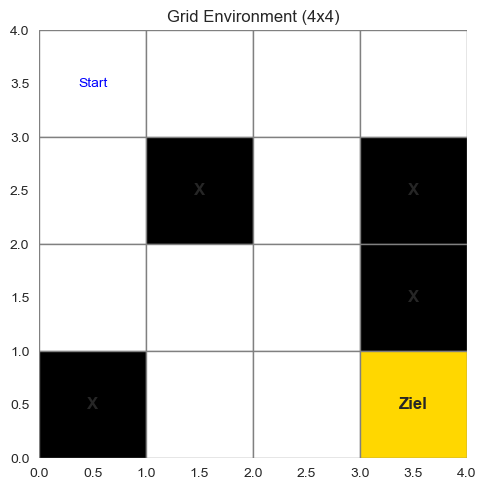

Belohnungen:  Ziel=+10, Hindernis=-5, normaler Schritt=-1


In [2]:
# Einfaches Grid-Environment
# 0=frei, -1=Hindernis, 10=Ziel
grid = np.array([
    [ 0,  0,  0,  0],
    [ 0, -1,  0, -1],
    [ 0,  0,  0, -1],
    [-1,  0,  0, 10]
])

fig, ax = plt.subplots(figsize=(5, 5))
colors = {0: 'white', -1: 'black', 10: 'gold'}
labels = {0: '', -1: 'X', 10: 'Ziel'}

for i in range(4):
    for j in range(4):
        val = grid[i, j]
        color = colors[val]
        rect = patches.Rectangle([j, 3-i], 1, 1, linewidth=1,
                                   edgecolor='gray', facecolor=color)
        ax.add_patch(rect)
        ax.text(j+0.5, 3-i+0.5, labels[val],
                ha='center', va='center', fontsize=12, fontweight='bold')

# Start markieren
ax.text(0.5, 3.5, 'Start', ha='center', va='center', fontsize=10, color='blue')
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.set_title('Grid Environment (4x4)')
plt.tight_layout()
plt.show()

print("Belohnungen:  Ziel=+10, Hindernis=-5, normaler Schritt=-1")

## Exploration vs. Exploitation

```
Exploitation: Nutze die beste bekannte Strategie
Exploration:  Probiere Neues aus — vielleicht gibt es etwas Besseres!

ε-Greedy Lösung:
  ε = 0.1  → 10% Exploration, 90% Exploitation
```

In [3]:
# ε-Greedy Strategie visualisieren
def epsilon_greedy(q_values, epsilon):
    if random.random() < epsilon:
        return random.randint(0, len(q_values)-1)  # Exploration
    else:
        return int(np.argmax(q_values))             # Exploitation

# Simulation: Wie oft wird jede Aktion gewählt?
q_values = [1.0, 3.0, 0.5, 2.0]  # Geschätzte Werte für 4 Aktionen
actionen = ['Links', 'Rechts', 'Hoch', 'Runter']

for epsilon in [0.0, 0.1, 0.5]:
    counts = [0, 0, 0, 0]
    for _ in range(1000):
        a = epsilon_greedy(q_values, epsilon)
        counts[a] += 1
    print(f"ε={epsilon}: {dict(zip(actionen, counts))}")

ε=0.0: {'Links': 0, 'Rechts': 1000, 'Hoch': 0, 'Runter': 0}
ε=0.1: {'Links': 27, 'Rechts': 913, 'Hoch': 31, 'Runter': 29}
ε=0.5: {'Links': 134, 'Rechts': 619, 'Hoch': 114, 'Runter': 133}


## Q-Learning — Der wichtigste RL-Algorithmus

```
Q-Tabelle: Für jeden (State, Action) wird ein Wert gespeichert

Update-Regel (Bellman):
Q(s,a) ← Q(s,a) + α × [r + γ × max Q(s',a') - Q(s,a)]

α = Lernrate (wie schnell wird gelernt)
γ = Discount-Faktor (wie wichtig ist die Zukunft)
r = erhaltene Belohnung
```

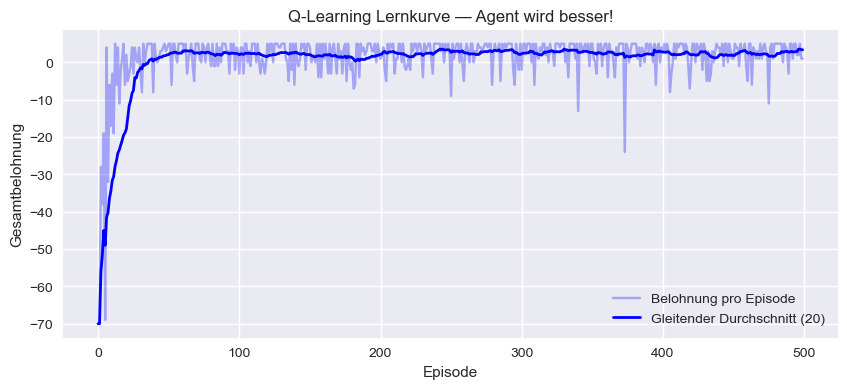

Erste 20 Episoden:  Ø -18.9
Letzte 20 Episoden: Ø 3.3


In [4]:
# Q-Learning auf dem Grid implementieren
# Aktionen: 0=hoch, 1=runter, 2=links, 3=rechts
ACTIONS = ['↑', '↓', '←', '→']
GRID_SIZE = 4

def step(state, action):
    r, c = state
    if action == 0: r = max(0, r-1)          # hoch
    elif action == 1: r = min(GRID_SIZE-1, r+1)  # runter
    elif action == 2: c = max(0, c-1)        # links
    elif action == 3: c = min(GRID_SIZE-1, c+1)  # rechts

    val = grid[r, c]
    if val == 10:
        return (r, c), 10, True   # Ziel erreicht
    elif val == -1:
        return state, -5, False   # Hindernis → zurück
    else:
        return (r, c), -1, False  # normaler Schritt

# Q-Tabelle initialisieren: (16 Zustände × 4 Aktionen)
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))

alpha   = 0.1   # Lernrate
gamma   = 0.9   # Discount-Faktor
epsilon = 0.2   # Exploration
episodes = 500

total_rewards = []

for ep in range(episodes):
    state = (0, 0)   # immer am Start beginnen
    total_r = 0

    for _ in range(50):  # max 50 Schritte pro Episode
        # Aktion wählen (ε-greedy)
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            action = int(np.argmax(Q[state[0], state[1]]))

        next_state, reward, done = step(state, action)
        total_r += reward

        # Q-Update (Bellman-Gleichung)
        old_q = Q[state[0], state[1], action]
        next_max = np.max(Q[next_state[0], next_state[1]])
        Q[state[0], state[1], action] = old_q + alpha * (reward + gamma * next_max - old_q)

        state = next_state
        if done:
            break

    total_rewards.append(total_r)

# Lernkurve plotten
window = 20
smoothed = [np.mean(total_rewards[max(0,i-window):i+1]) for i in range(len(total_rewards))]

plt.figure(figsize=(10, 4))
plt.plot(total_rewards, alpha=0.3, color='blue', label='Belohnung pro Episode')
plt.plot(smoothed, color='blue', linewidth=2, label=f'Gleitender Durchschnitt ({window})')
plt.xlabel('Episode')
plt.ylabel('Gesamtbelohnung')
plt.title('Q-Learning Lernkurve — Agent wird besser!')
plt.legend()
plt.show()

print(f"Erste 20 Episoden:  Ø {np.mean(total_rewards[:20]):.1f}")
print(f"Letzte 20 Episoden: Ø {np.mean(total_rewards[-20:]):.1f}")

In [ ]:
# Gelernte Policy visualisieren
fig, ax = plt.subplots(figsize=(5, 5))
arrow_map = {0: '↑', 1: '↓', 2: '←', 3: '→'}

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        val = grid[i, j]
        color = 'white' if val == 0 else ('black' if val == -1 else 'gold')
        rect = patches.Rectangle([j, 3-i], 1, 1, linewidth=1,
                                   edgecolor='gray', facecolor=color)
        ax.add_patch(rect)

        if val == 0:
            best_action = int(np.argmax(Q[i, j]))
            ax.text(j+0.5, 3-i+0.5, arrow_map[best_action],
                    ha='center', va='center', fontsize=18)
        elif val == 10:
            ax.text(j+0.5, 3-i+0.5, 'ZIEL', ha='center', va='center',
                    fontsize=10, fontweight='bold')
        else:
            ax.text(j+0.5, 3-i+0.5, 'X', ha='center', va='center',
                    fontsize=14, color='white', fontweight='bold')

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.set_title('Gelernte Policy (nach 500 Episoden)')
plt.tight_layout()
plt.show()

## RL vs. Supervised Learning — wann was?

| Frage | Supervised | RL |
|-------|:---:|:---:|
| Gibt es korrekte Labels? | ✅ | ❌ |
| Muss man Entscheidungssequenzen lernen? | ❌ | ✅ |
| Feedback ist sofort? | ✅ | Oft verzögert |
| Beispiele: | Spam-Filter, Diagnose | Spiele, Robotik, RLHF |

## Wo steckt RL in der Praxis?

```
ChatGPT / Claude:  RLHF — Menschen bewerten Antworten → Modell verbessert sich
Netflix-Feed:      Agent lernt welche Thumbnails du anklickst
Werbung:           Agent lernt wann welche Anzeige zeigen
AlphaGo:           Agent lernt Schach/Go durch Millionen Selbstspiele
```